# Análise exploratória dos dados
_EDA - Exploratory Data Analysis_

---

## Sumário

1. **Importação de bibliotecas**
2. **Carregamento da base**
3. **Análise do dataframe**
   - 3.1. Volumetria
   - 3.2. Tipagem, Nulos e Cardinalidade
   - 3.3. Duplicidade
   - 3.4. Medidas Estatísticas
   - 3.5. Boxplot e Outliers das Variáveis Numéricas
   - 3.6. Distribuição das Variáveis Numéricas
   - 3.7. Análise da Distribuição das Variáveis Numéricas
4. **Análise exploratória dos dados**
   - 4.1. Impacto do problema
      - 4.1.1. Taxa de churn
      - 4.1.2. Estimativa de impacto financeiro
      - 4.1.3. Métricas de churn por decil
   - 4.2. Relação bancária
      - 4.2.1. Número de produtos
      - 4.2.2. Atividade do cliente
      - 4.2.3. Saldo bancário
      - 4.2.4. Score de crédito
   - 4.3. Perfil de Risco
      - 4.3.1. Idade
      - 4.3.2. Tempo como cliente
      - 4.3.3. Geografia
      - 4.3.4. Gênero

5. **Insights e recomendações**

<br>

---

<br>

## 1. Importação de bibliotecas

In [87]:
# Importação de bibliotecas e definições de parâmetros

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from scipy import stats
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter


In [88]:
# Configurações para exibição de dados no Jupyter Notebook

# Configurar opção para exibir todas as linhas do Dataframe
pd.set_option('display.max_rows', None)

# Configurar para exibir o conteúdo completo das colunas
pd.set_option('display.max_colwidth', None)

# Configurar a supressão de mensagens de aviso durante a execução
warnings.filterwarnings('ignore')

# Configurar estilo dos gráficos do seaborn
sns.set_style('whitegrid')

## 2. Carregamento da base

In [89]:
# Criando um dataframe a partir do arquivo CSV
df = pd.read_csv('../data/raw/Churn_Modelling.csv', sep=',', encoding='utf-8')
df.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


## 3. Análise do dataframe

### 3.1. Volumetria

In [90]:
# Exibindo a quantidade de linhas e coluna do dataframe

print(f'Quantidade de linhas (registros):  {df.shape[0]}')
print(f'Quantidade de colunas (variáveis): {df.shape[1]}') 

Quantidade de linhas (registros):  10000
Quantidade de colunas (variáveis): 14


### 3.2. Tipagem, Nulos e Cardinalidade

In [91]:
def gerar_metadados(dataframe):
    '''
    Gera um dataframe contendo metadados das colunas do dataframe fornecido.

    :param dataframe: Dataframe
        DataFrame para o qual os metadados serão gerados.
    :return: DataFrame
        DataFrame contendo os metadados.
    '''

    # Calculando as métricas
    metadata = pd.DataFrame({
        'Variável': dataframe.columns,
        'Tipo de Dado': dataframe.dtypes.values,
        'Quantidade de Valores Únicos': dataframe.nunique().values,
        'Quantidade de Valores Nulos': dataframe.isnull().sum().values,
        'Porcentagem de Valores Nulos': (dataframe.isnull().mean() * 100).values
    })

    return metadata

In [92]:
# Exibindo os metadados do dataframe

gerar_metadados(df)

,Variável,Tipo de Dado,Quantidade de Valores Únicos,Quantidade de Valores Nulos,Porcentagem de Valores Nulos
0,RowNumber,int64,10000,0,0.0
1,CustomerId,int64,10000,0,0.0
2,Surname,str,2932,0,0.0
3,CreditScore,int64,460,0,0.0
4,Geography,str,3,0,0.0
5,Gender,str,2,0,0.0
6,Age,int64,70,0,0.0
7,Tenure,int64,11,0,0.0
8,Balance,float64,6382,0,0.0
9,NumOfProducts,int64,4,0,0.0


### 3.3. Duplicidade

In [93]:
# Exibindo a quantidade de registros únicos e duplicados no dataframe

contagem_duplicados = df.duplicated().value_counts().rename(
    index={False: 'Registros Únicos', True: 'Registros Duplicados'})
print(contagem_duplicados)

Registros Únicos    10000
Name: count, dtype: int64


### 3.4. Medidas Estatísticas

In [94]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


In [95]:
df.describe(exclude=('float', 'int')).T

,count,unique,top,freq
Surname,10000,2932,Smith,32
Geography,10000,3,France,5014
Gender,10000,2,Male,5457


### 3.5. Boxplot e Outliers das Variáveis Numéricas

In [96]:
# Colunas a serem removidas da análise dos dados numéricos

colunas_remover = ['RowNumber', 'CustomerId', 'Tenure', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Exited']

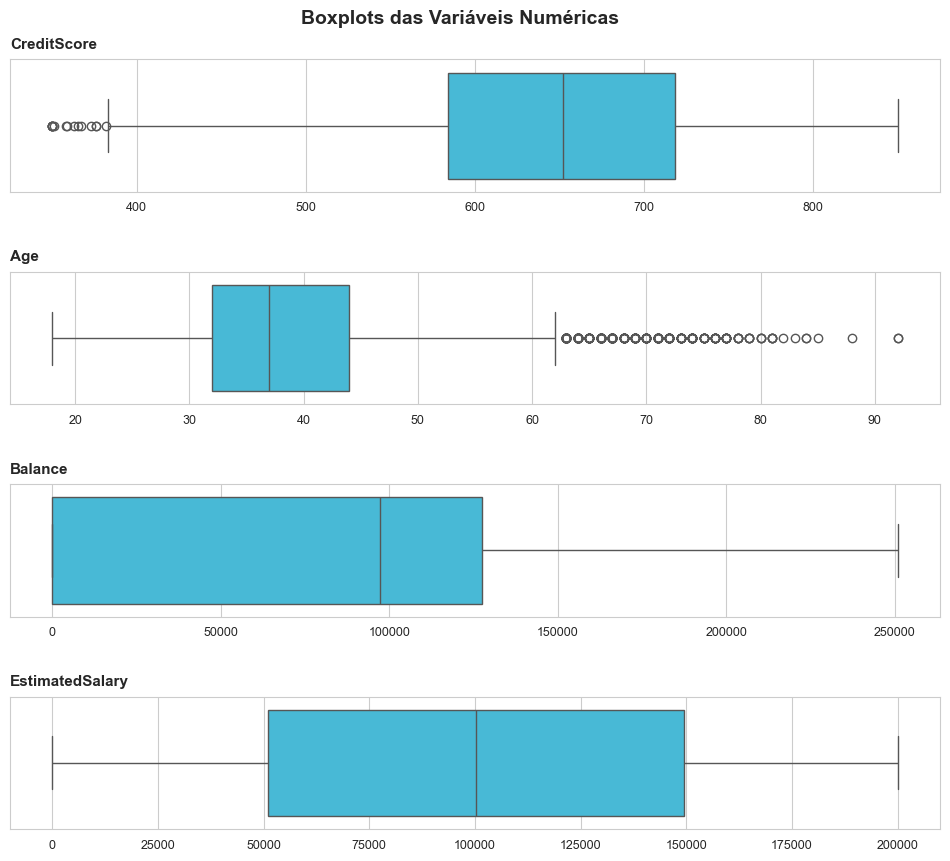

In [97]:
# Seleciona os nomes das colunas numéricas (float apenas)
colunas_numericas = df.select_dtypes(include=['number']).columns.tolist()
colunas_numericas = [col for col in colunas_numericas if col not in colunas_remover] 

# Verifica se há colunas numéricas
if not colunas_numericas:
    print('Nenhuma variável numérica encontrada no DataFrame.')
else:
    # Número de boxplots a serem gerados
    n_plots = len(colunas_numericas)

    # Cria a figura com subplots verticais
    fig, axs = plt.subplots(n_plots, 1, figsize=(12, 2.5 * n_plots), 
                            gridspec_kw={'hspace': 0.6})

    # Garante que axs seja sempre uma lista (mesmo com 1 gráfico)
    if n_plots == 1:
        axs = [axs]

    # Loop pelas colunas para criar os boxplots
    for ax, col in zip(axs, colunas_numericas):
        sns.boxplot(x=df[col], ax=ax, color='#31c7ed', orient='h')
        ax.set_title(f'{col}', loc='left', fontsize=11, pad=8, fontweight='bold')
        ax.set(xlabel='', ylabel='')
        ax.tick_params(labelsize=9)
        ax.ticklabel_format(style='plain', axis='x')

    # Ajusta o layout e adiciona título geral
    fig.suptitle('Boxplots das Variáveis Numéricas', fontsize=14, fontweight='bold', y=0.93)
    plt.tight_layout(rect=[0, 0, 1, 0.97])  # evita sobreposição com título
    plt.show()

In [98]:
# Seleciona as variáveis numéricas
colunas_numericas = df.select_dtypes(include=['number']).columns.tolist()
colunas_numericas = [col for col in colunas_numericas if col not in colunas_remover] 

# Lista para armazenar as informações de outliers por coluna
resultados_outliers = []

for col in colunas_numericas:
    # Calcula quartis e intervalo interquartil (IIQ)
    Q1 = df[col].quantile(.25)
    Q3 = df[col].quantile(.75)
    IIQ = Q3 - Q1

    # Define limites inferior e superior para outliers
    limite_inferior = Q1 - 1.5 * IIQ
    limite_superior = Q3 + 1.5 * IIQ

    # Contagem de outliers abaixo e acima dos limites
    outliers_abaixo = (df[col] < limite_inferior).sum()
    outliers_acima = (df[col] > limite_superior).sum()
    
    # Calcula a quantidade total de outliers fora dos limites
    total_outliers = outliers_acima + outliers_abaixo
    
    # Calcula a porcentagem total de outliers fora dos limites
    total_outliers_perc = total_outliers / df.shape[0]
    
    # Armazena resultados em um dicionário
    resultados_outliers.append({
        'Variável': col,
        'IIQ': IIQ,
        'Limite Inferior': limite_inferior,
        'Limite Superior': limite_superior,
        'Outliers Abaixo': outliers_abaixo,
        'Outliers Acima': outliers_acima,
        'Total Outliers': total_outliers,
        '% Outliers': round(total_outliers_perc * 100, 3)
    })
    
# Converte a lista de dicionários em um DataFrame
df_outliers = pd.DataFrame(resultados_outliers) 

# Ordena o DataFrame pela % de outliers em ordem decrescente
df_outliers.sort_values(by='% Outliers', ascending=False, inplace=True)  

# Exibe o DataFrame com os resultados
print('\nResumo dos Outliers por Variável (ordenado por maior %)')
display(df_outliers.reset_index(drop=True))


Resumo dos Outliers por Variável (ordenado por maior %)


,Variável,IIQ,Limite Inferior,Limite Superior,Outliers Abaixo,Outliers Acima,Total Outliers,% Outliers
0,Age,12.0000,14.00000,62.00000,0,359,359,3.59
1,CreditScore,134.0000,383.00000,919.00000,15,0,15,0.15
2,Balance,127644.2400,-191466.36000,319110.60000,0,0,0,0.00
3,EstimatedSalary,98386.1375,-96577.09625,296967.45375,0,0,0,0.00



---

**Insights extraídos**

- **CreditScore**

    Existem pontuações muito baixas (abaixo de ~400–450) que aparecem como outliers no boxplot. Esses casos representam uma pequena parcela da base.
    Embora o dataset apresente alguns clientes com crédito muito baixo, a análise isolada da distribuição não permite afirmar relação direta com churn.

- **Age**

    Observam-se alguns outliers em idades acima de ~60 anos, indicando a presença de clientes mais idosos na base, porém em baixa quantidade relativa.
    A maior concentração de clientes está entre aproximadamente 30 e 50 anos. Esse intervalo tende a representar o perfil predominante da base.

- **Balance**

    A distribuição de saldo apresenta um comportamento particular, existe uma grande concentração de clientes com saldo igual a zero.
    Esse padrão sugere a existência de um segmento distinto de clientes sem saldo ativo na conta.

- **EstimatedSalary**

    A variável de salário estimado apresenta distribuição relativamente equilibrada ao longo da faixa de valores, sem evidência clara de outliers.
    Visualmente, não há indicação de concentração específica que sugira um comportamento diferenciado apenas pela distribuição geral.

---


### 3.6. Distribuição das Variáveis Numéricas

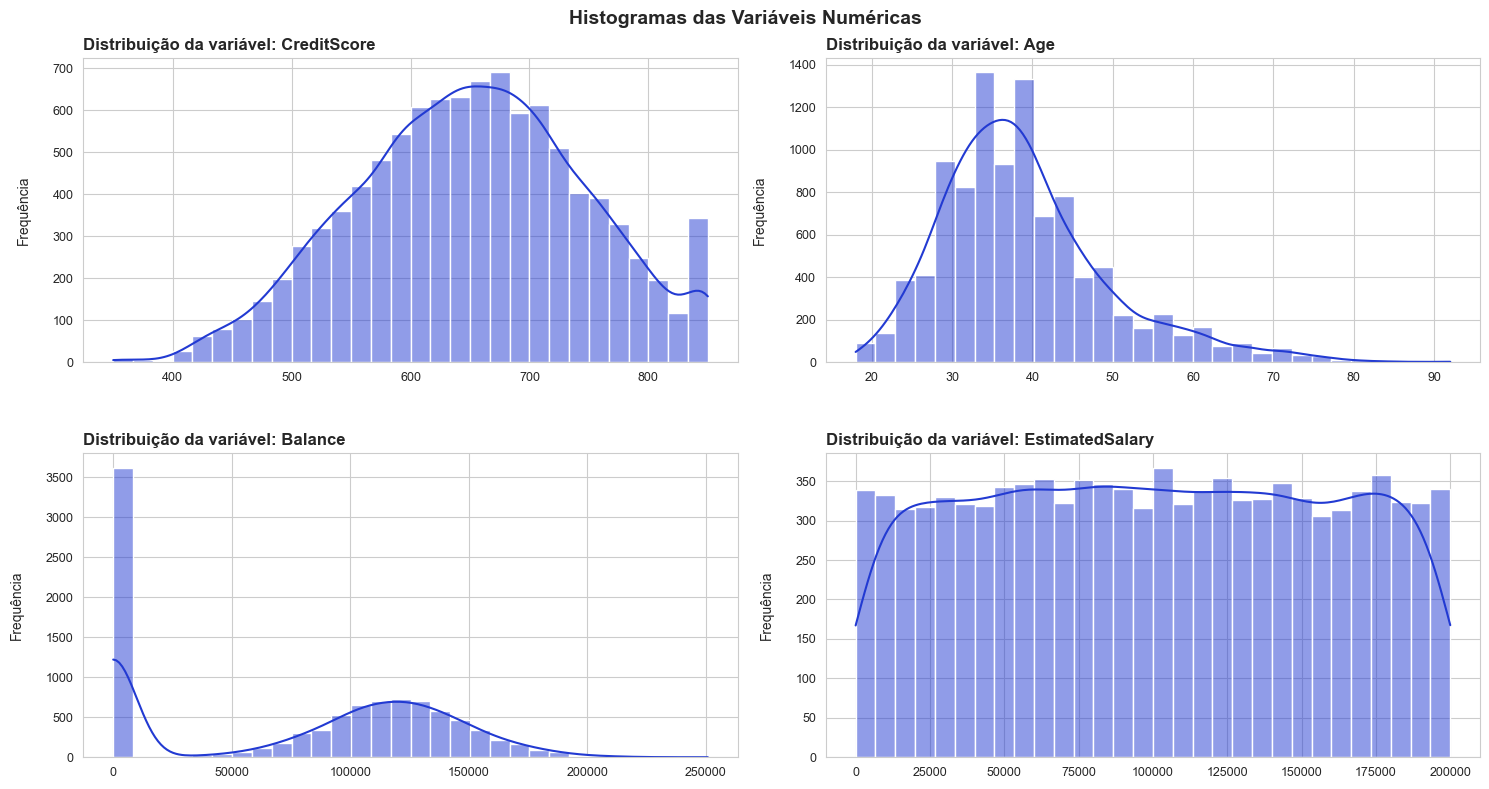

In [99]:
# Seleciona as variáveis numéricas
colunas_numericas = df.select_dtypes(include=['number']).columns.tolist()
colunas_numericas = [col for col in colunas_numericas if col not in colunas_remover] 

# Calcula a quantidade de subplots necessários
qtde_subplots = len(colunas_numericas)

# Configuração para múltiplos gráficos: 2 colunas por linha
colunas_subplot = 2
qtde_linhas = -(-qtde_subplots // colunas_subplot)

# Criação da figura com subplots
fig, axs = plt.subplots(qtde_linhas, colunas_subplot, figsize=(15, 4 * qtde_linhas))

# Transformação do array de subplots para facilitar o loop
axs = axs.flatten()

# Remove subplots vazios, caso existam
for i in range(qtde_subplots, len(axs)):
    fig.delaxes(axs[i])

# Loop sobre as variáveis numéricas para criar os histogramas
for i, coluna in enumerate(colunas_numericas):
    sns.histplot(data=df, x=coluna, ax=axs[i], bins=30, kde=True, color='#223ad2', edgecolor='#ffffff')

    # Configura o título e remove os rótulos dos eixos
    axs[i].set_title(f'Distribuição da variável: {coluna}', fontsize=12, loc='left', fontweight='bold')
    axs[i].set(xlabel='', ylabel='Frequência\n')

    # Ajusta o tamanho dos rótulos
    axs[i].tick_params(labelsize=9)

    # Exibe rótulos sem notação científica
    axs[i].ticklabel_format(style='plain', axis='x')

# Adiciona um título geral
fig.suptitle('Histogramas das Variáveis Numéricas', fontsize=14, fontweight='bold')

# Ajusta o layout para evitar sobreposição
plt.tight_layout()
plt.subplots_adjust(hspace=0.3, top=0.92)  # Mais espaço entre os gráficos
plt.show()


---

**Insights extraídos**

As variáveis numéricas apresentam distribuições distintas e, em geral, não seguem um padrão perfeitamente simétrico.

- **CreditScore** apresenta maior concentração em valores intermediários, com presença de cauda em pontuações mais baixas.

- **Age** mostra distribuição levemente assimétrica, com predominância de clientes em idade adulta e menor presença de clientes muito jovens ou muito idosos.

- **Balance** apresenta forte concentração em zero, indicando a existência de um grupo relevante de clientes sem saldo em conta. Esse comportamento pode representar perfis de relacionamento diferentes com o banco.

- **EstimatedSalary** apresenta distribuição mais uniforme em comparação às demais variáveis, sugerindo menor concentração em faixas específicas.

Esses padrões indicam que a base contém diferentes perfis de clientes, reforçando a importância de análises segmentadas para entender possíveis relações com churn.

---


### 3.7. Análise da Distribuição das Variáveis Numéricas

In [100]:
def teste_normalidade(dataframe, col):
    '''
    Realiza testes estatísticos de normalidade (Shapiro-Wilk e D’Agostino-Pearson)
    para a variável numérica especificada.

    :param dataframe: DataFrame
        DataFrame contendo os dados a serem analisados.
    :param col: str
        Nome da coluna numérica a ser testada.
    :return: None
        Exibe os resultados dos testes e interpretação.
    '''

    # Remove valores ausentes da amostra
    amostra = dataframe[col].dropna()

    # Teste de Shapiro-Wilk
    shapiro_stat, shapiro_p = stats.shapiro(amostra)

    # Teste de D’Agostino-Pearson
    dagostino_stat, dagostino_p = stats.normaltest(amostra)

    # Exibição dos resultados
    print(f'\n📌 Teste de Normalidade — {coluna}\n')
    print(f'- Shapiro-Wilk:       Estatística = {shapiro_stat:.4f} | p-valor = {shapiro_p:.4f}')
    print(f'- D\'Agostino-Pearson: Estatística = {dagostino_stat:.4f} | p-valor = {dagostino_p:.4f}\n')

    # Interpretação
    if shapiro_p > 0.05 and dagostino_p > 0.05:
        print('✅ A variável apresenta distribuição normal (não rejeita H₀ nos dois testes).\n')
    else:
        print('⚠️ A variável não apresenta distribuição normal (rejeita H₀ em pelo menos um teste).\n')

In [101]:
# Seleciona as variáveis numéricas para os testes de normalidade
vars_teste = df.select_dtypes(include=['number']).columns.tolist()
vars_teste = [col for col in vars_teste if col not in colunas_remover] 

# Realiza os testes de normalidade para cada variável numérica selecionada
for coluna in vars_teste:
    teste_normalidade(df, coluna)


📌 Teste de Normalidade — CreditScore

- Shapiro-Wilk:       Estatística = 0.9939 | p-valor = 0.0000
- D'Agostino-Pearson: Estatística = 132.8284 | p-valor = 0.0000

⚠️ A variável não apresenta distribuição normal (rejeita H₀ em pelo menos um teste).


📌 Teste de Normalidade — Age

- Shapiro-Wilk:       Estatística = 0.9441 | p-valor = 0.0000
- D'Agostino-Pearson: Estatística = 1507.7909 | p-valor = 0.0000

⚠️ A variável não apresenta distribuição normal (rejeita H₀ em pelo menos um teste).


📌 Teste de Normalidade — Balance

- Shapiro-Wilk:       Estatística = 0.8456 | p-valor = 0.0000
- D'Agostino-Pearson: Estatística = 62973.3895 | p-valor = 0.0000

⚠️ A variável não apresenta distribuição normal (rejeita H₀ em pelo menos um teste).


📌 Teste de Normalidade — EstimatedSalary

- Shapiro-Wilk:       Estatística = 0.9566 | p-valor = 0.0000
- D'Agostino-Pearson: Estatística = 7397.1498 | p-valor = 0.0000

⚠️ A variável não apresenta distribuição normal (rejeita H₀ em pelo menos um teste

---

**Insights extraídos**

As quatro variáveis analisadas não apresentam distribuição normal.

Distribuições assimétricas ou com múltiplos picos geralmente indicam a presença de diferentes segmentos dentro da base de clientes, refletindo comportamentos ou perfis distintos.

Por esse motivo, a presença de diferentes padrões de distribuição sugere que análises segmentadas, considerando idade, saldo ou nível de crédito, podem revelar diferenças importantes no comportamento de churn.

---

## 4. Análise exploratória dos dados

### 4.1. Impacto do problema

#### 4.1.1. Taxa de churn

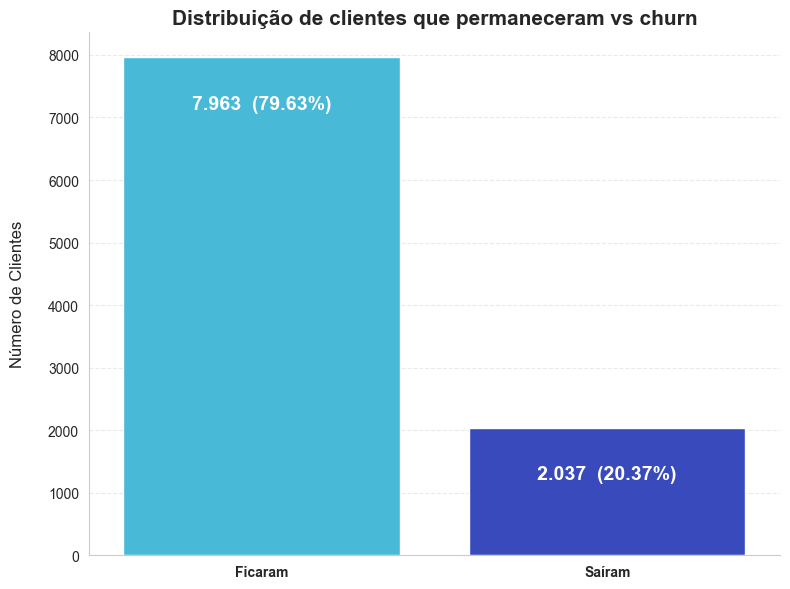

In [102]:
# Contagem de clientes
churn_counts = df['Exited'].value_counts().sort_index()

labels = ['Ficaram', 'Saíram']
values = churn_counts.values

# Criando figura
plt.figure(figsize=(8,6))

# Paleta
colors = ['#31c7ed','#223ad2']

ax = sns.barplot(x=labels, y=values, palette=colors)

# Título
plt.title('Distribuição de clientes que permaneceram vs churn',
          fontsize=15, fontweight='bold')
plt.xlabel('')
plt.ylabel('Número de Clientes\n', fontsize=12)

# Inserindo valores e porcentagem nas barras
total = sum(values)
for p in ax.patches:
    height = p.get_height()
    percentual = height / total * 100
    ax.annotate(
        f'{int(height):,}  ({percentual:.2f}%)'.replace(',', '.'),
        (p.get_x() + p.get_width()/2, height),
        ha='center', va='bottom',
        xytext=(0, -40),  # Distância do texto para a barra
        textcoords='offset points',
        fontsize=14,
        fontweight='bold',
        color='#fff',
    )

# Exibe rótulos sem notação científica
ax.ticklabel_format(style='plain', axis='y')

# Ajustando o eixo x aplicando negrito
ax.set_xticklabels(ax.get_xticklabels(), fontweight='bold')

# Removendo bordas extras
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Exibindo o gráfico
plt.tight_layout()
plt.show()

In [103]:
# Cálculo da taxa de churn
total_clientes = len(df)
clientes_churn = df['Exited'].sum()
taxa_churn = clientes_churn / total_clientes

# Apresentação dos resultados
print('\n📊 Análise de Churn de Clientes')
print('-' * 35)

print(f'\nTotal de clientes analisados: {total_clientes}')
print(f'Clientes que saíram (churn):   {clientes_churn}')

print(f'\nA taxa de churn é de {taxa_churn:.2%}.')
print(f'\n⚠️ Isto significa que {clientes_churn} de cada {total_clientes} clientes encerraram o relacionamento com a empresa.\n')


📊 Análise de Churn de Clientes
-----------------------------------

Total de clientes analisados: 10000
Clientes que saíram (churn):   2037

A taxa de churn é de 20.37%.

⚠️ Isto significa que 2037 de cada 10000 clientes encerraram o relacionamento com a empresa.



#### 4.1.2. Estimativa de impacto financeiro

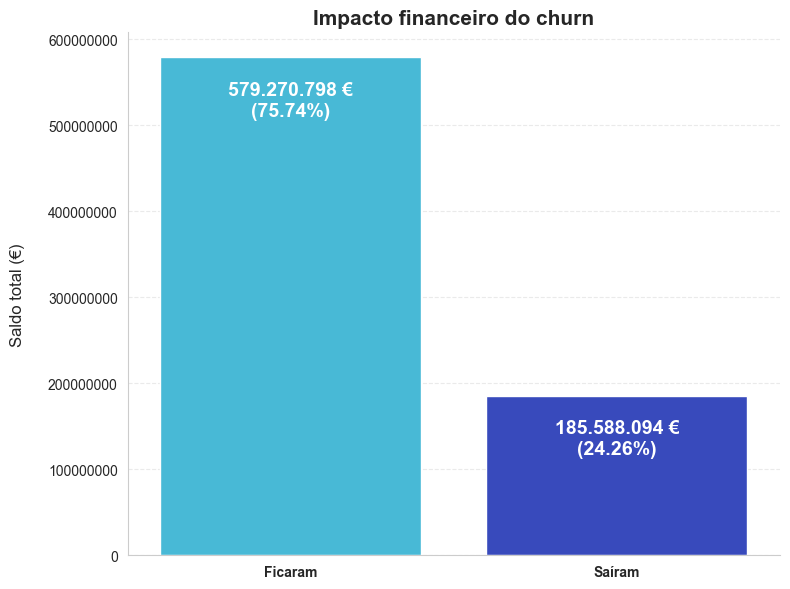

In [104]:
# Calculando saldos por grupo
saldo_por_grupo = df.groupby('Exited')['Balance'].sum()
total_saldo = saldo_por_grupo.sum()

# Labels
labels = ['Ficaram', 'Saíram']
values = saldo_por_grupo.values
percentuais = values / total_saldo * 100

# Criando figura
plt.figure(figsize=(8,6))

# Paleta
colors = ['#31c7ed','#223ad2']

ax = sns.barplot(x=labels, y=values, palette=colors)

# Título
plt.title('Impacto financeiro do churn', fontsize=15, fontweight='bold')
plt.xlabel('')
plt.ylabel('Saldo total (€)\n', fontsize=12)

# Adicionando valores e percentuais nas barras
for i, p in enumerate(ax.patches):
    height = p.get_height()
    ax.annotate(
        f'{int(height):,} €\n({percentuais[i]:.2f}%)'.replace(',', '.'),
        (p.get_x() + p.get_width()/2, height),
        ha='center', va='bottom',
        xytext=(0, -45),
        textcoords='offset points',
        fontsize=14,
        fontweight='bold',
        color='white'
    )

# Remove notação científica
ax.ticklabel_format(style='plain', axis='y')

# Ajustando o eixo x aplicando negrito
ax.set_xticklabels(ax.get_xticklabels(), fontweight='bold')

# Removendo bordas extras
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Exibindo o gráfico
plt.tight_layout()
plt.show()

In [105]:
# Cálculo de saldos
saldo_total = df['Balance'].sum()
saldo_churn = df[df['Exited'] == 1]['Balance'].sum()
saldo_stay = df[df['Exited'] == 0]['Balance'].sum()

impacto_percentual_churn = saldo_churn / saldo_total
impacto_percentual_stay = saldo_stay / saldo_total

avg_balance_churn = df[df['Exited'] == 1]['Balance'].mean()
avg_balance_stay = df[df['Exited'] == 0]['Balance'].mean()

# Apresentação dos resultados
print('\n💰 Análise de Impacto Financeiro do Churn')
print('-' * 40)

print(f'\nSaldo total dos clientes: {saldo_total:,.2f} €\n')
print(f'Saldo total de churn: {saldo_churn:,.2f} €')
print(f'Percentual do saldo total afetado: {impacto_percentual_churn:.2%}\n')
print(f'Saldo total não afetado: {saldo_stay:,.2f} €')
print(f'Percentual do saldo total não afetado: {impacto_percentual_stay:.2%}')

print(f'\nSaldo médio dos clientes que saíram: {avg_balance_churn:,.2f} €')
print(f'Saldo médio dos clientes que permaneceram: {avg_balance_stay:,.2f} €')

print('\n⚠️ Mais de 20% do saldo total está sendo perdido com churn.\n')



💰 Análise de Impacto Financeiro do Churn
----------------------------------------

Saldo total dos clientes: 764,858,892.88 €

Saldo total de churn: 185,588,094.63 €
Percentual do saldo total afetado: 24.26%

Saldo total não afetado: 579,270,798.25 €
Percentual do saldo total não afetado: 75.74%

Saldo médio dos clientes que saíram: 91,108.54 €
Saldo médio dos clientes que permaneceram: 72,745.30 €

⚠️ Mais de 20% do saldo total está sendo perdido com churn.



#### 4.1.3. Métricas de churn por decil

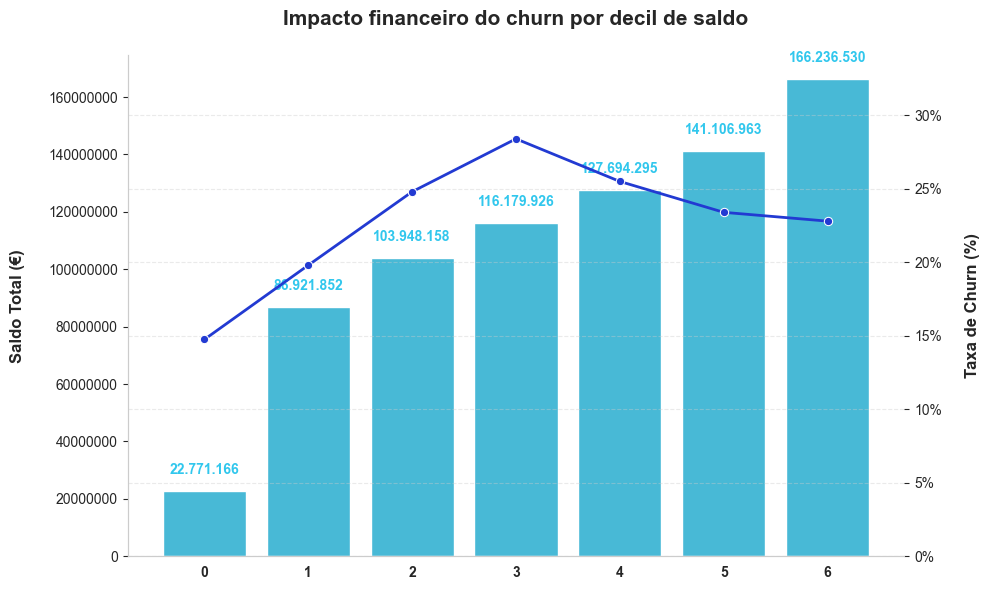

In [106]:
# Decis por saldo (Balance)
df['balance_decile'] = pd.qcut(df['Balance'], 10, labels=False, duplicates='drop')

# Agrupamento por decil de saldo
decile_analysis = (
    df.groupby('balance_decile').agg(
        total_clientes=('Exited', 'count'),
        taxa_churn=('Exited', 'mean'),
        avg_balance=('Balance', 'mean'),
        total_balance=('Balance', 'sum')
    )
).reset_index()

# Percentual do saldo total
decile_analysis['percentual_saldo'] = (decile_analysis['total_balance'] / 
    decile_analysis['total_balance'].sum() * 100)

# Gráfico
fig, ax1 = plt.subplots(figsize=(10,6))

# Eixo principal - saldo total
colors = sns.color_palette(['#31c7ed'], n_colors=10)
sns.barplot(
    x='balance_decile',
    y='total_balance',
    data=decile_analysis,
    palette=colors,
    ax=ax1
)

# Adicionando os valores nas barras
for p in ax1.patches:
    ax1.annotate(
        f'{int(p.get_height()):,}'.replace(',', '.'),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom',
        fontsize=10, fontweight='bold',
        color='#31c7ed',
        xytext=(0, 10),
        textcoords='offset points'
    )

ax1.set_xticklabels(ax1.get_xticklabels(), fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Saldo Total (€)\n', fontsize=12, fontweight='bold')
ax1.set_title('Impacto financeiro do churn por decil de saldo\n', fontsize=15, fontweight='bold')

# Remover as linhas de grade
ax1.grid(False)

# Eixo secundário - taxa de churn
ax2 = ax1.twinx()
sns.lineplot(
    x='balance_decile',
    y='taxa_churn',
    data=decile_analysis,
    color='#223ad2',
    marker='o',
    linewidth=2,
    ax=ax2
)
ax2.set_ylabel('\nTaxa de Churn (%)', fontsize=12, fontweight='bold')
ax2.set_ylim(0, decile_analysis['taxa_churn'].max() * 1.2)
ax2.set_yticklabels([f'{y*100:.0f}%' for y in ax2.get_yticks()])

# Remove notação científica
ax1.ticklabel_format(style='plain', axis='y')

# Removendo bordas extras
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Exibindo o gráfico
plt.tight_layout()
plt.show()

In [107]:
# Análise por decil de saldo
decile_analysis = (
    df.groupby('balance_decile').agg(
        total_clientes=('Exited', 'count'),
        taxa_churn=('Exited', 'mean'),
        avg_balance=('Balance', 'mean'),
        total_balance=('Balance', 'sum')
      )
)

# Formatação dos resultados
decile_analysis['Total de clientes'] = decile_analysis['total_clientes'].apply(lambda x: f'{x:.0f}')
decile_analysis['Taxa de churn (%)'] = decile_analysis['taxa_churn'].apply(lambda x: f'{x*100:.2f}')
decile_analysis['Saldo médio (€)'] = decile_analysis['avg_balance'].apply(lambda x: f'{x:,.2f}')
decile_analysis['Saldo total (€)'] = decile_analysis['total_balance'].apply(lambda x: f'{x:,.2f}')

# Remover colunas numéricas originais
decile_analysis = decile_analysis.drop(columns=[
    'total_clientes', 'taxa_churn', 'avg_balance', 'total_balance'])

# Renomear índice
decile_analysis.index.name = 'Decil'

# Exibir tabela final
decile_analysis

,Total de clientes,Taxa de churn (%),Saldo médio (€),Saldo total (€)
Decil,,,,
0,4000,14.75,"5,692.79","22,771,166.64"
1,1000,19.80,"86,921.85","86,921,852.04"
2,1000,24.80,"103,948.16","103,948,158.39"
3,1000,28.40,"116,179.93","116,179,926.02"
4,1000,25.50,"127,694.30","127,694,295.87"
5,1000,23.40,"141,106.96","141,106,963.06"
6,1000,22.80,"166,236.53","166,236,530.86"


### 4.2. Relação bancária

#### 4.2.1. Número de produtos

In [108]:
# Agrupamento por número de produtos (NumOfProducts)
product_analysis = (
    df.groupby('NumOfProducts').agg(
        total_clientes=('Exited','count'),
        taxa_churn=('Exited','mean'),
        avg_balance=('Balance','mean'),
        total_balance=('Balance','sum')
    ).reset_index()
)

# Percentual do saldo total
product_analysis['percentual_saldo'] = product_analysis['total_balance'] / product_analysis['total_balance'].sum() * 100

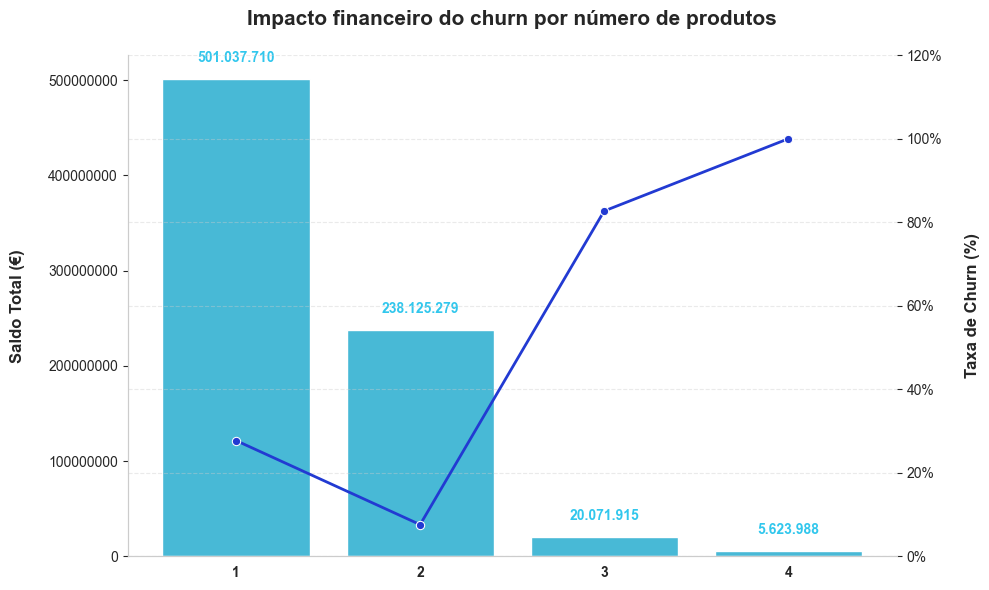

In [109]:
# Gráfico
fig, ax1 = plt.subplots(figsize=(10,6))

# Eixo principal - saldo total
colors = sns.color_palette(['#31c7ed'], n_colors=10)
sns.barplot(
    x='NumOfProducts',
    y='total_balance',
    data=product_analysis,
    palette=colors,
    ax=ax1
)

# Adicionando os valores nas barras
for p in ax1.patches:
    ax1.annotate(
        f'{int(p.get_height()):,}'.replace(',', '.'),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom',
        fontsize=10, fontweight='bold',
        color='#31c7ed',
        xytext=(0, 10),
        textcoords='offset points'
    )

ax1.set_xticklabels(ax1.get_xticklabels(), fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Saldo Total (€)\n', fontsize=12, fontweight='bold')
ax1.set_title('Impacto financeiro do churn por número de produtos\n', fontsize=15, fontweight='bold')

# Remover as linhas de grade
ax1.grid(False)

# Posições das barras
x_positions = range(len(product_analysis))

# Eixo secundário - taxa de churn
ax2 = ax1.twinx()
sns.lineplot(
    x=x_positions,
    y='taxa_churn',
    data=product_analysis,
    color='#223ad2',
    marker='o',
    linewidth=2,
    ax=ax2
)
ax2.set_ylabel('\nTaxa de Churn (%)', fontsize=12, fontweight='bold')
ax2.set_ylim(0, product_analysis['taxa_churn'].max() * 1.2)
ax2.set_yticklabels([f'{y*100:.0f}%' for y in ax2.get_yticks()])

# Remove notação científica
ax1.ticklabel_format(style='plain', axis='y')

# Removendo bordas extras
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Exibindo o gráfico
plt.tight_layout()
plt.show()

In [110]:
# Formatação dos resultados
product_analysis['Total de clientes'] = product_analysis['total_clientes'].apply(lambda x: f'{x:.0f}')
product_analysis['Taxa de churn (%)'] = product_analysis['taxa_churn'].apply(lambda x: f'{x:.2%}')
product_analysis['Saldo médio (€)'] = product_analysis['avg_balance'].apply(lambda x: f'{x:,.2f}')
product_analysis['Saldo total (€)'] = product_analysis['total_balance'].apply(lambda x: f'{x:,.2f}')

# Remover colunas numéricas originais
product_analysis = product_analysis.drop(columns=['percentual_saldo','total_clientes', 'taxa_churn', 'avg_balance', 'total_balance'])

# Renomear colunas para apresentação
product_analysis.rename(columns={'NumOfProducts': 'Número de produtos'}, inplace=True)

# Exibir tabela final
product_analysis

,Número de produtos,Total de clientes,Taxa de churn (%),Saldo médio (€),Saldo total (€)
0,1,5084,27.71%,"98,551.87","501,037,710.20"
1,2,4590,7.58%,"51,879.15","238,125,279.28"
2,3,266,82.71%,"75,458.33","20,071,915.30"
3,4,60,100.00%,"93,733.13","5,623,988.10"


#### 4.2.2. Atividade do cliente

In [111]:
# Agrupamento por clientes ativos (IsActiveMember)
isactivemember_analysis = (
    df.groupby('IsActiveMember').agg(
        total_clientes=('Exited','count'),
        taxa_churn=('Exited','mean'),
        avg_balance=('Balance','mean'),
        total_balance=('Balance','sum')
    ).reset_index()
)

# Percentual do saldo total
isactivemember_analysis['percentual_saldo'] = (
    isactivemember_analysis['total_balance'] / isactivemember_analysis['total_balance'].sum() * 100)

# Mapear 0/1 para Não/Sim
isactivemember_analysis['IsActiveMember'] = (
    isactivemember_analysis['IsActiveMember']
    .map({0: 'Inativo', 1: 'Ativo'})
)

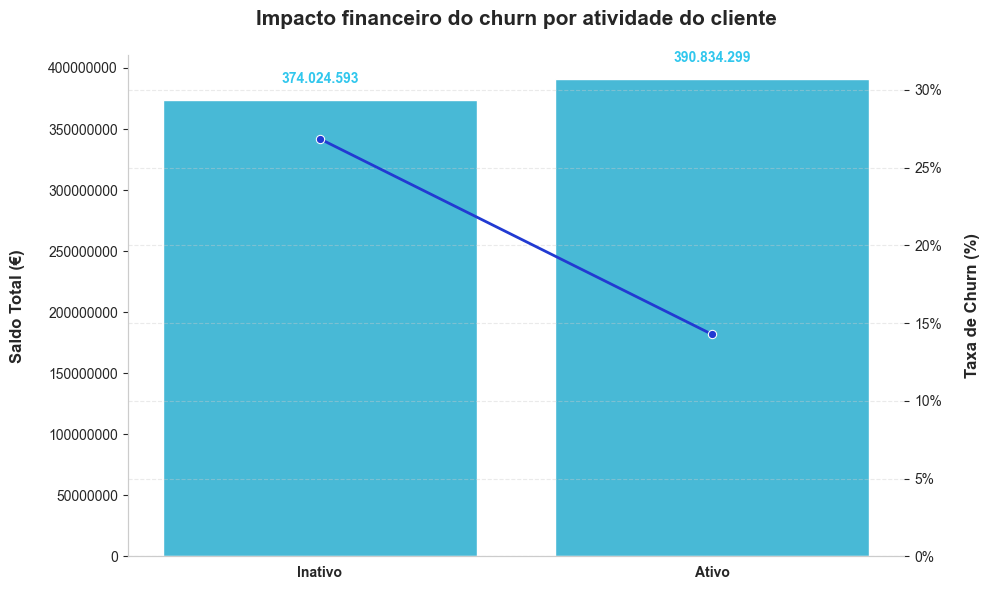

In [112]:
# Gráfico
fig, ax1 = plt.subplots(figsize=(10,6))

# Eixo principal - saldo total
colors = sns.color_palette(['#31c7ed'], n_colors=10)
sns.barplot(
    x='IsActiveMember',
    y='total_balance',
    data=isactivemember_analysis,
    palette=colors,
    ax=ax1
)

# Adicionando os valores nas barras
for p in ax1.patches:
    ax1.annotate(
        f'{int(p.get_height()):,}'.replace(',', '.'),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom',
        fontsize=10, fontweight='bold',
        color='#31c7ed',
        xytext=(0, 10),
        textcoords='offset points'
    )

ax1.set_xticklabels(ax1.get_xticklabels(), fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Saldo Total (€)\n', fontsize=12, fontweight='bold')
ax1.set_title('Impacto financeiro do churn por atividade do cliente\n', fontsize=15, fontweight='bold')

# Remover as linhas de grade
ax1.grid(False)

# Posições das barras
x_positions = range(len(isactivemember_analysis))

# Eixo secundário - taxa de churn
ax2 = ax1.twinx()
sns.lineplot(
    x=x_positions,
    y='taxa_churn',
    data=isactivemember_analysis,
    color='#223ad2',
    marker='o',
    linewidth=2,
    ax=ax2
)
ax2.set_ylabel('\nTaxa de Churn (%)', fontsize=12, fontweight='bold')
ax2.set_ylim(0, isactivemember_analysis['taxa_churn'].max() * 1.2)
ax2.set_yticklabels([f'{y*100:.0f}%' for y in ax2.get_yticks()])

# Remove notação científica
ax1.ticklabel_format(style='plain', axis='y')

# Removendo bordas extras
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Exibindo o gráfico
plt.tight_layout()
plt.show()

In [113]:
# Formatação dos resultados
isactivemember_analysis['Total de clientes'] = isactivemember_analysis['total_clientes'].apply(lambda x: f'{x:.0f}')
isactivemember_analysis['Taxa de churn (%)'] = isactivemember_analysis['taxa_churn'].apply(lambda x: f'{x:.2%}')
isactivemember_analysis['Saldo médio (€)'] = isactivemember_analysis['avg_balance'].apply(lambda x: f'{x:,.2f}')
isactivemember_analysis['Saldo total (€)'] = isactivemember_analysis['total_balance'].apply(lambda x: f'{x:,.2f}')

# Remover colunas numéricas originais
isactivemember_analysis = isactivemember_analysis.drop(columns=[
    'percentual_saldo','total_clientes', 'taxa_churn', 'avg_balance', 'total_balance'])

# Renomear colunas para apresentação
isactivemember_analysis.rename(columns={'IsActiveMember': 'Membro ativo'}, inplace=True)

# Exibir tabela final
isactivemember_analysis

,Membro ativo,Total de clientes,Taxa de churn (%),Saldo médio (€),Saldo total (€)
0,Inativo,4849,26.85%,"77,134.38","374,024,593.41"
1,Ativo,5151,14.27%,"75,875.42","390,834,299.47"


#### 4.2.3. Saldo bancário

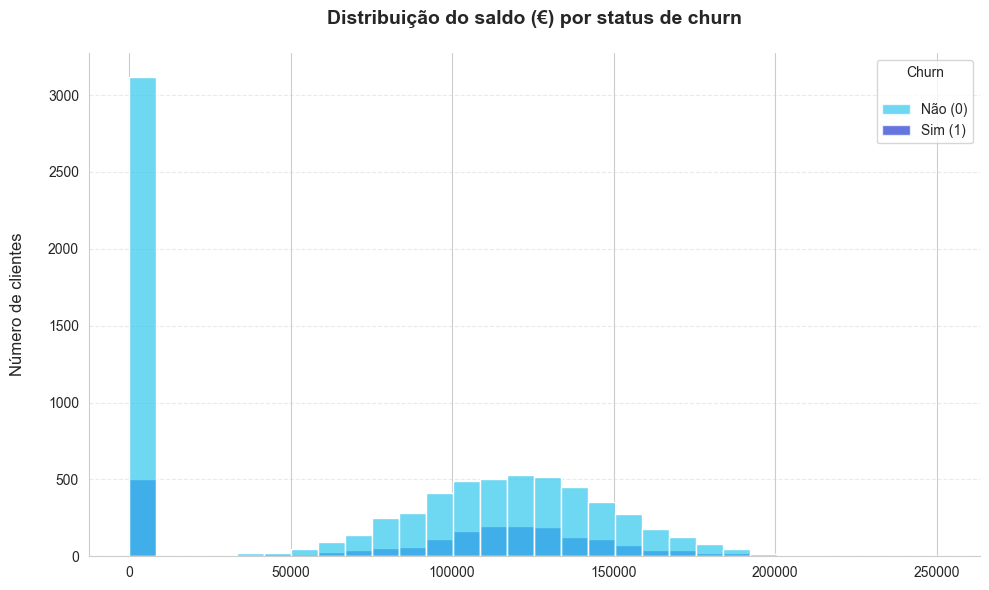

In [114]:
# Histograma do saldo por status de churn
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='Balance',
    hue='Exited',
    palette={0:'#31c7ed', 1:'#223ad2'},
    bins=30,
    kde=False,
    alpha=0.7
)

plt.xlabel('')
plt.ylabel('Número de clientes\n', fontsize=12)
plt.title('Distribuição do saldo (€) por status de churn\n', fontsize=14, fontweight='bold')

# Ajustando eixo y para não usar notação científica
plt.ticklabel_format(style='plain', axis='y')

# Removendo bordas extras
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Criando legenda manual
legend_elements = [
    Patch(facecolor='#31c7ed', label='Não (0)', alpha=0.7),
    Patch(facecolor='#223ad2', label='Sim (1)', alpha=0.7)
]
plt.legend(handles=legend_elements, title='Churn\n')

# Exibindo o gráfico
plt.tight_layout()
plt.show()

In [115]:
# Agrupar por churn (Exited)
balance_stats = (
    df.groupby('Exited')['Balance']
    .agg(
        media='mean',
        maximo='max',
        minimo='min',
        total_clientes='count'
    )
)

# Formatação dos resultados
balance_stats['Total de clientes'] = balance_stats['total_clientes'].apply(lambda x: f'{x:.0f}')
balance_stats['Saldo Médio (€)'] = balance_stats['media'].apply(lambda x: f'{x:,.2f}')
balance_stats['Saldo Máximo (€)'] = balance_stats['maximo'].apply(lambda x: f'{x:,.2f}')
balance_stats['Saldo Mínimo (€)'] = balance_stats['minimo'].apply(lambda x: f'{x:,.2f}')

# Remover colunas numéricas originais
balance_stats = balance_stats.drop(columns=['total_clientes', 'media', 'maximo', 'minimo'])

# Renomear índice
balance_stats.index = balance_stats.index.map({0: 'Não Churn', 1: 'Churn'})
balance_stats.index.name = 'Status do Cliente'

# Exibir resultado
balance_stats

,Total de clientes,Saldo Médio (€),Saldo Máximo (€),Saldo Mínimo (€)
Status do Cliente,,,,
Não Churn,7963,"72,745.30","221,532.80",0.00
Churn,2037,"91,108.54","250,898.09",0.00


#### 4.2.4. Score de crédito

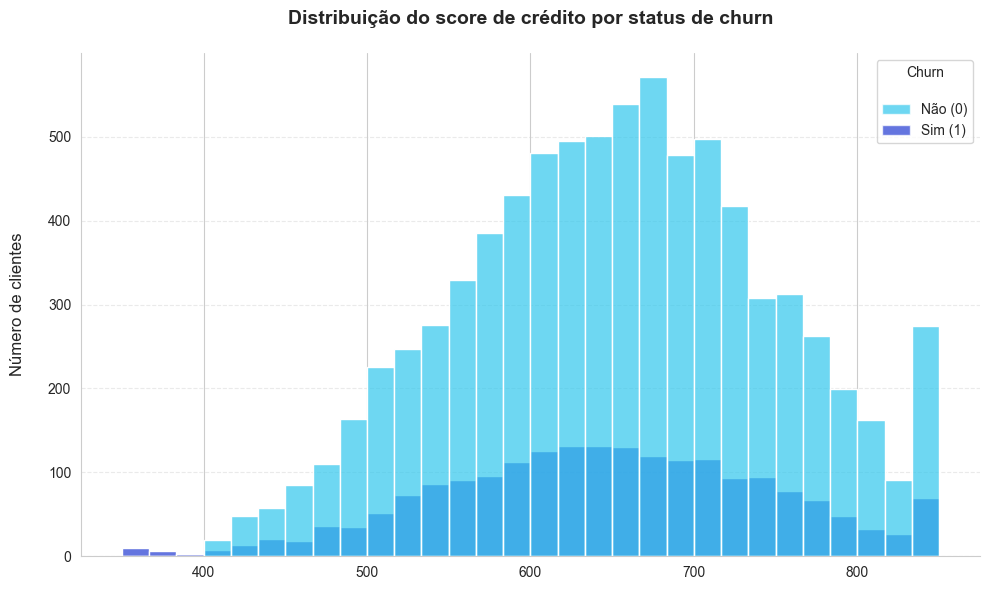

In [116]:
# Histograma do CreditScore por status de churn
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='CreditScore',
    hue='Exited',
    palette={0:'#31c7ed', 1:'#223ad2'},
    bins=30,
    kde=False,
    alpha=0.7
)

plt.xlabel('')
plt.ylabel('Número de clientes\n', fontsize=12)
plt.title('Distribuição do score de crédito por status de churn\n', fontsize=14, fontweight='bold')

# Ajustando eixo y para não usar notação científica
plt.ticklabel_format(style='plain', axis='y')

# Removendo bordas extras
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Criando legenda manual
legend_elements = [
    Patch(facecolor='#31c7ed', label='Não (0)', alpha=0.7),
    Patch(facecolor='#223ad2', label='Sim (1)', alpha=0.7)
]
plt.legend(handles=legend_elements, title='Churn\n')

# Exibindo o gráfico
plt.tight_layout()
plt.show()

In [117]:
# Quintis por score de crédito (CreditScore)
df['creditScore_quintil'] = pd.qcut(df['CreditScore'], 5, labels=False, duplicates='drop')

# Agrupamento por quintil
creditScore_analysis = (
    df.groupby('creditScore_quintil').agg(
        total_clientes=('Exited', 'count'),
        taxa_churn=('Exited', 'mean'),
        avg_balance=('Balance', 'mean'),
        total_balance=('Balance', 'sum')
    )
).reset_index()

# Percentual do saldo total
creditScore_analysis['percentual_saldo'] = (
    creditScore_analysis['total_balance'] /
    creditScore_analysis['total_balance'].sum() * 100
)

# Formatação dos resultados
creditScore_analysis['Total de clientes'] = creditScore_analysis['total_clientes'].apply(lambda x: f'{x:.0f}')
creditScore_analysis['Taxa de churn (%)'] = creditScore_analysis['taxa_churn'].apply(lambda x: f'{x*100:.2f}')
creditScore_analysis['Saldo médio (€)'] = creditScore_analysis['avg_balance'].apply(lambda x: f'{x:,.2f}')
creditScore_analysis['Saldo total (€)'] = creditScore_analysis['total_balance'].apply(lambda x: f'{x:,.2f}')
creditScore_analysis['Percentual do saldo total (%)'] = creditScore_analysis['percentual_saldo'].apply(lambda x: f'{x:.2f}')

# Remover colunas numéricas originais
creditScore_analysis = creditScore_analysis.drop(columns=[
    'creditScore_quintil','total_clientes', 'taxa_churn', 'avg_balance', 'total_balance', 'percentual_saldo'])

# Renomear índice
creditScore_analysis.index = creditScore_analysis.index.map({
    0: 'Muito baixo', 1: 'Baixo', 2: 'Médio', 3: 'Bom', 4: 'Excelente'
})
creditScore_analysis.index.name = 'Quintil'

# Exibir tabela final
creditScore_analysis

,Total de clientes,Taxa de churn (%),Saldo médio (€),Saldo total (€),Percentual do saldo total (%)
Quintil,,,,,
Muito baixo,2010,22.49,"76,087.28","152,935,428.85",20.00
Baixo,2020,20.84,"75,008.65","151,517,466.01",19.81
Médio,2010,19.65,"77,820.17","156,418,550.96",20.45
Bom,1981,18.32,"75,413.11","149,393,370.80",19.53
Excelente,1979,20.52,"78,117.27","154,594,076.26",20.21


### 4.3. Perfil de Risco

#### 4.3.1. Idade

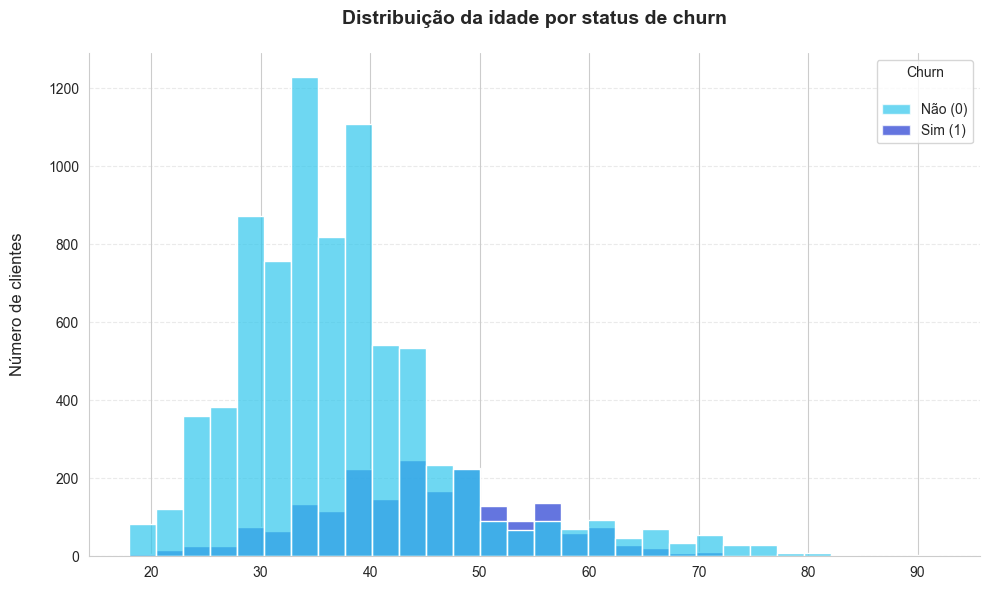

In [118]:
# Histograma de idade (Age) por status de churn
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='Age',
    hue='Exited',
    palette={0:'#31c7ed', 1:'#223ad2'},
    bins=30,
    kde=False,
    alpha=0.7
)

plt.xlabel('')
plt.ylabel('Número de clientes\n', fontsize=12)
plt.title('Distribuição da idade por status de churn\n', fontsize=14, fontweight='bold')

# Ajustando eixo y para não usar notação científica
plt.ticklabel_format(style='plain', axis='y')

# Removendo bordas extras
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Criando legenda manual
legend_elements = [
    Patch(facecolor='#31c7ed', label='Não (0)', alpha=0.7),
    Patch(facecolor='#223ad2', label='Sim (1)', alpha=0.7)
]
plt.legend(handles=legend_elements, title='Churn\n')

# Exibindo o gráfico
plt.tight_layout()
plt.show()

In [119]:
# Criar faixas etárias com labels amigáveis
bins = [18, 30, 40, 50, 60, 100]
labels = ['18-30', '31-40', '41-50', '51-60', '61+']

df['age_group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

# Agrupamento por faixa etária
age_analysis = (
    df.groupby('age_group').agg(
        total_clientes=('Exited', 'count'),
        taxa_churn=('Exited', 'mean'),
        avg_balance=('Balance', 'mean'),
        total_balance=('Balance', 'sum')
      ).reset_index()
)

# Formatação dos resultados
age_analysis['Total de clientes'] = age_analysis['total_clientes'].apply(lambda x: f'{x:.0f}')
age_analysis['Taxa de Churn (%)'] = age_analysis['taxa_churn'].apply(lambda x: f'{x:.2f}')
age_analysis['Saldo Médio (€)'] = age_analysis['avg_balance'].apply(lambda x: f'{x:,.2f}')
age_analysis['Saldo Total (€)'] = age_analysis['total_balance'].apply(lambda x: f'{x:,.2f}')

# Remover colunas numéricas originais
age_analysis = age_analysis.drop(columns=['total_clientes', 'taxa_churn', 'avg_balance', 'total_balance'])

# Renomear colunas para apresentação
age_analysis.rename(columns={'age_group': 'Faixa etária'}, inplace=True)

# Exibir tabela final
age_analysis

,Faixa etária,Total de clientes,Taxa de Churn (%),Saldo Médio (€),Saldo Total (€)
0,18-30,1946,0.08,"73,131.26","142,313,437.00"
1,31-40,4451,0.12,"75,583.36","336,421,546.13"
2,41-50,2320,0.34,"79,122.19","183,563,488.83"
3,51-60,797,0.56,"82,401.66","65,674,125.54"
4,61+,464,0.25,"75,742.60","35,144,564.73"


#### 4.3.2. Tempo como cliente

In [120]:
# Criar faixas de Tenure de 2 em 2 anos
bins = [0, 2, 4, 6, 8, 10, float('inf')]
labels = ['1 ano ou menos','2 a 3 anos','4 a 5 anos','6 a 7 anos','8 a 9 anos','10 anos ou mais']

df['tenure_group'] = pd.cut(df['Tenure'], bins=bins, labels=labels, right=False, include_lowest=True)

# Agrupamento por faixa de ano (Tenure)
tenure_analysis = (
    df.groupby('tenure_group').agg(
        total_clientes=('Exited','count'),
        taxa_churn=('Exited','mean'),
        avg_balance=('Balance','mean'),
        total_balance=('Balance','sum')
    ).reset_index()
)

# Percentual do saldo total
tenure_analysis['percentual_saldo'] = (
    tenure_analysis['total_balance'] / tenure_analysis['total_balance'].sum() * 100)

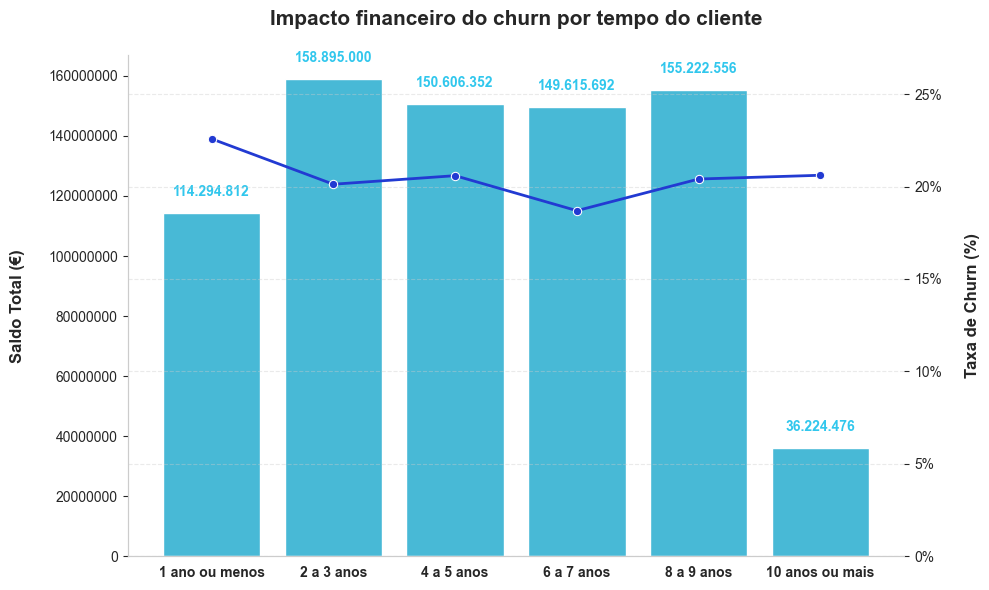

In [121]:
# Gráfico
fig, ax1 = plt.subplots(figsize=(10,6))

# Eixo principal - saldo total
sns.barplot(
    x='tenure_group',
    y='total_balance',
    data=tenure_analysis,
    color='#31c7ed',
    ax=ax1
)

# Adicionando os valores nas barras
for p in ax1.patches:
    ax1.annotate(
        f'{int(p.get_height()):,}'.replace(',', '.'),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom',
        fontsize=10, fontweight='bold',
        color='#31c7ed',
        xytext=(0, 10),
        textcoords='offset points'
    )

ax1.set_xticklabels(ax1.get_xticklabels(), fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Saldo Total (€)\n', fontsize=12, fontweight='bold')
ax1.set_title('Impacto financeiro do churn por tempo do cliente\n', fontsize=15, fontweight='bold')

# Remover as linhas de grade
ax1.grid(False)

# Eixo secundário - taxa de churn
ax2 = ax1.twinx()
sns.lineplot(
    x='tenure_group',
    y='taxa_churn',
    data=tenure_analysis,
    color='#223ad2',
    marker='o',
    linewidth=2,
    ax=ax2
)
ax2.set_ylabel('\nTaxa de Churn (%)', fontsize=12, fontweight='bold')
ax2.set_ylim(0, tenure_analysis['taxa_churn'].max() * 1.2)
ax2.set_yticklabels([f'{y*100:.0f}%' for y in ax2.get_yticks()])

# Remove notação científica
ax1.ticklabel_format(style='plain', axis='y')

# Removendo bordas extras
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Exibindo o gráfico
plt.tight_layout()
plt.show()


In [122]:
# Formatação dos resultados
tenure_analysis['Total de clientes'] = tenure_analysis['total_clientes'].apply(lambda x: f'{x:.0f}')
tenure_analysis['Taxa de churn (%)'] = tenure_analysis['taxa_churn'].apply(lambda x: f'{x:.2%}')
tenure_analysis['Saldo médio (€)'] = tenure_analysis['avg_balance'].apply(lambda x: f'{x:,.2f}')
tenure_analysis['Saldo total (€)'] = tenure_analysis['total_balance'].apply(lambda x: f'{x:,.2f}')

# Remover colunas numéricas originais
tenure_analysis = tenure_analysis.drop(columns=['percentual_saldo','total_clientes', 'taxa_churn', 'avg_balance', 'total_balance'])

# Renomear colunas para apresentação
tenure_analysis.rename(columns={'tenure_group': 'Faixa de anos'}, inplace=True)

# Exibir tabela final
tenure_analysis

,Faixa de anos,Total de clientes,Taxa de churn (%),Saldo médio (€),Saldo total (€)
0,1 ano ou menos,1448,22.58%,"78,932.88","114,294,812.76"
1,2 a 3 anos,2057,20.13%,"77,245.99","158,895,000.96"
2,4 a 5 anos,2001,20.59%,"75,265.54","150,606,352.96"
3,6 a 7 anos,1995,18.70%,"74,995.33","149,615,692.72"
4,8 a 9 anos,2009,20.41%,"77,263.59","155,222,556.52"
5,10 anos ou mais,490,20.61%,"73,927.50","36,224,476.96"


#### 4.3.3. Geografia

In [123]:
# Agrupamento por país (Geography)
geography_analysis = (
    df.groupby('Geography').agg(
        total_clientes=('Exited','count'),
        taxa_churn=('Exited','mean'),
        avg_balance=('Balance','mean'),
        total_balance=('Balance','sum')
    ).reset_index()
)

# Percentual do saldo total
geography_analysis['percentual_saldo'] = (
    geography_analysis['total_balance'] / geography_analysis['total_balance'].sum() * 100)

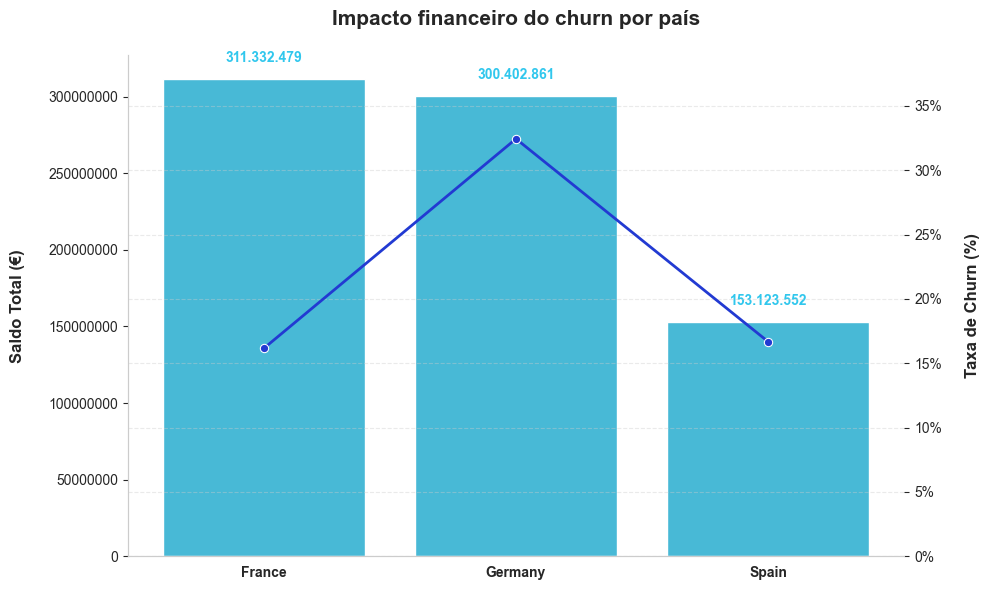

In [124]:
# Gráfico
fig, ax1 = plt.subplots(figsize=(10,6))

# Eixo principal - saldo total
sns.barplot(
    x='Geography',
    y='total_balance',
    data=geography_analysis,
    palette=['#31c7ed'],
    ax=ax1
)

# Adicionando os valores nas barras
for p in ax1.patches:
    ax1.annotate(
        f'{int(p.get_height()):,}'.replace(',', '.'),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom',
        fontsize=10, fontweight='bold',
        color='#31c7ed',
        xytext=(0, 10),
        textcoords='offset points'
    )

ax1.set_xticklabels(ax1.get_xticklabels(), fontweight='bold')
for label in ax1.get_xticklabels():
    label.set_fontweight('bold')

ax1.set_xlabel('')
ax1.set_ylabel('Saldo Total (€)\n', fontsize=12, fontweight='bold')
ax1.set_title('Impacto financeiro do churn por país\n', fontsize=15, fontweight='bold')

# Remover as linhas de grade
ax1.grid(False)

# Eixo secundário - taxa de churn
ax2 = ax1.twinx()
sns.lineplot(
    x='Geography',
    y='taxa_churn',
    data=geography_analysis,
    color='#223ad2',
    marker='o',
    linewidth=2,
    ax=ax2
)
ax2.set_ylabel('\nTaxa de Churn (%)', fontsize=12, fontweight='bold')
ax2.set_ylim(0, geography_analysis['taxa_churn'].max() * 1.2)
ax2.set_yticklabels([f'{y*100:.0f}%' for y in ax2.get_yticks()])

# Remove notação científica
ax1.ticklabel_format(style='plain', axis='y')

# Removendo bordas extras
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Exibindo o gráfico
plt.tight_layout()
plt.show()


In [125]:
# Formatação dos resultados
geography_analysis['Total de clientes'] = geography_analysis['total_clientes'].apply(lambda x: f'{x:.0f}')
geography_analysis['Taxa de churn (%)'] = geography_analysis['taxa_churn'].apply(lambda x: f'{x:.2%}')
geography_analysis['Saldo médio (€)'] = geography_analysis['avg_balance'].apply(lambda x: f'{x:,.2f}')
geography_analysis['Saldo total (€)'] = geography_analysis['total_balance'].apply(lambda x: f'{x:,.2f}')

# Remover colunas numéricas originais
geography_analysis = geography_analysis.drop(columns=['percentual_saldo','total_clientes', 'taxa_churn', 'avg_balance', 'total_balance'])

# Renomear colunas para apresentação
geography_analysis.rename(columns={'Geography': 'País'}, inplace=True)

# Exibir tabela final
geography_analysis

,País,Total de clientes,Taxa de churn (%),Saldo médio (€),Saldo total (€)
0,France,5014,16.15%,"62,092.64","311,332,479.49"
1,Germany,2509,32.44%,"119,730.12","300,402,861.38"
2,Spain,2477,16.67%,"61,818.15","153,123,552.01"


#### 4.3.4. Gênero

In [126]:
# Agrupamento por gênero (Gender)
gender_analysis = (
    df.groupby('Gender').agg(
        total_clientes=('Exited','count'),
        taxa_churn=('Exited','mean'),
        avg_balance=('Balance','mean'),
        total_balance=('Balance','sum')
    ).reset_index()
)

# Percentual do saldo total
gender_analysis['percentual_saldo'] = (
    gender_analysis['total_balance'] / gender_analysis['total_balance'].sum() * 100)

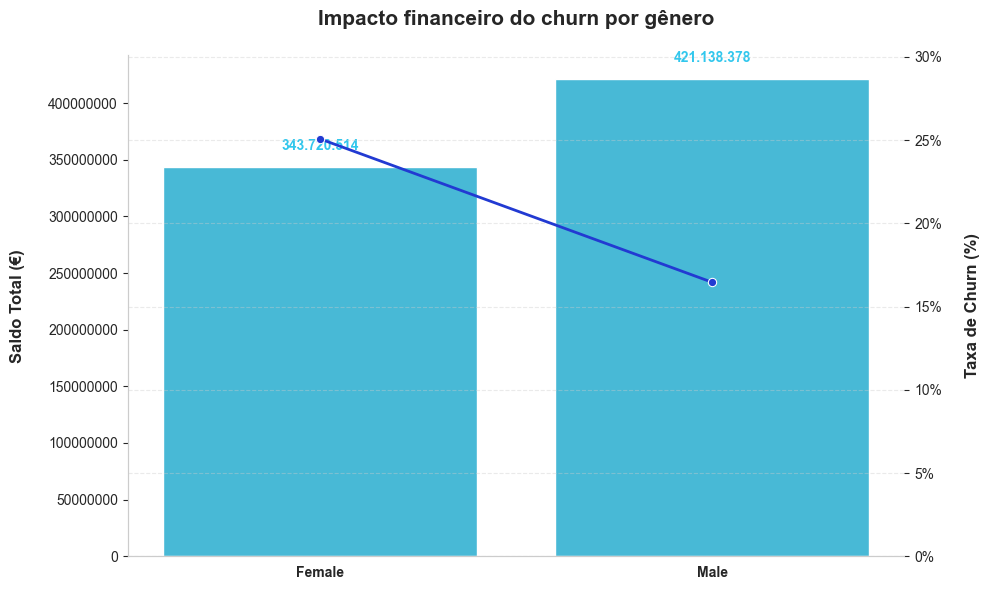

In [127]:
# Gráfico
fig, ax1 = plt.subplots(figsize=(10,6))

# Eixo principal - saldo total
sns.barplot(
    x='Gender',
    y='total_balance',
    data=gender_analysis,
    palette=['#31c7ed'],
    ax=ax1
)

# Adicionando os valores nas barras
for p in ax1.patches:
    ax1.annotate(
        f'{int(p.get_height()):,}'.replace(',', '.'),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom',
        fontsize=10, fontweight='bold',
        color='#31c7ed',
        xytext=(0, 10),
        textcoords='offset points'
    )

ax1.set_xticklabels(ax1.get_xticklabels(), fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Saldo Total (€)\n', fontsize=12, fontweight='bold')
ax1.set_title('Impacto financeiro do churn por gênero\n', fontsize=15, fontweight='bold')

# Remover as linhas de grade
ax1.grid(False)

# Eixo secundário - taxa de churn
ax2 = ax1.twinx()
sns.lineplot(
    x='Gender',
    y='taxa_churn',
    data=gender_analysis,
    color='#223ad2',
    marker='o',
    linewidth=2,
    ax=ax2
)
ax2.set_ylabel('\nTaxa de Churn (%)', fontsize=12, fontweight='bold')
ax2.set_ylim(0, gender_analysis['taxa_churn'].max() * 1.2)
ax2.set_yticklabels([f'{y*100:.0f}%' for y in ax2.get_yticks()])

# Remove notação científica
ax1.ticklabel_format(style='plain', axis='y')

# Removendo bordas extras
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Exibindo o gráfico
plt.tight_layout()
plt.show()


In [128]:
# Formatação dos resultados
gender_analysis['Total de clientes'] = gender_analysis['total_clientes'].apply(lambda x: f'{x:.0f}')
gender_analysis['Taxa de churn (%)'] = gender_analysis['taxa_churn'].apply(lambda x: f'{x:.2%}')
gender_analysis['Saldo médio (€)'] = gender_analysis['avg_balance'].apply(lambda x: f'{x:,.2f}')
gender_analysis['Saldo total (€)'] = gender_analysis['total_balance'].apply(lambda x: f'{x:,.2f}')

# Remover colunas numéricas originais
gender_analysis = gender_analysis.drop(columns=['percentual_saldo','total_clientes', 'taxa_churn', 'avg_balance', 'total_balance'])

# Renomear colunas para apresentação
gender_analysis.rename(columns={'Gender': 'Gênero'}, inplace=True)

# Exibir tabela final
gender_analysis

,Gênero,Total de clientes,Taxa de churn (%),Saldo médio (€),Saldo total (€)
0,Female,4543,25.07%,"75,659.37","343,720,514.00"
1,Male,5457,16.46%,"77,173.97","421,138,378.88"
